# CartGuard | Retail Review Triage

CartGuard builds reproducible review triage pipelines for apparel retail. It predicts **non-recommendation**, a proxy for dissatisfied customers, from review text, age and product categories. Product-separated evaluation, missing-data stress tests and leakage-safe resampling make model decisions reviewable before operational adoption.

The strongest validation-selected pipeline achieved **0.795 test average precision**, **82.6% recall** and **68.4% precision** at a validation-selected threshold of 0.29. These are benchmark results, not measured revenue or customer-service savings.

![Precision–recall comparison](reports/figures/precision_recall.png)



In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

root = Path.cwd()
if not (root / "reports").exists():
    root = root.parent
metadata = json.loads((root / "reports/run_metadata.json").read_text())
display(pd.read_csv(root / "reports/test_metrics.csv"))

,id,scenario,strategy,imputation,average_precision,roc_auc,f1,precision,recall,accuracy,log_loss,brier,threshold
0,imbalance_none,natural,none,median,0.635630,0.905302,0.636775,0.565113,0.729253,0.859618,0.281859,0.088053,0.30
1,imbalance_under_half,natural,under_half,median,0.633501,0.905321,0.634236,0.568724,0.716805,0.860494,0.325636,0.101157,0.51
2,imbalance_under_equal,natural,under_equal,median,0.627879,0.903350,0.625954,0.551861,0.723029,0.854192,0.427402,0.135940,0.67
3,imbalance_over_equal,natural,over_equal,median,0.632332,0.905254,0.635112,0.542647,0.765560,0.851567,0.412108,0.130269,0.62
4,imbalance_smotenc,natural,smotenc,median,0.627143,0.901494,0.629283,0.551052,0.733402,0.854192,0.373525,0.117380,0.59
5,imbalance_weighted,natural,weighted,median,0.632395,0.905358,0.635911,0.563753,0.729253,0.859093,0.414978,0.131482,0.66
6,imbalance_full_text,natural,full_text,median,0.794774,0.950462,0.748472,0.684437,0.825726,0.906354,0.221082,0.065110,0.29
7,imputation_mean,mcar20,none,mean,0.627160,0.902824,0.631720,0.555994,0.731328,0.856118,0.285136,0.089327,0.29
8,imputation_median,mcar20,none,median,0.627053,0.902840,0.631203,0.554595,0.732365,0.855593,0.285089,0.089322,0.29
9,imputation_knn,mcar20,none,knn,0.626224,0.902796,0.628143,0.546431,0.738589,0.852442,0.285223,0.089350,0.28


## Evaluation protocol and interpretation

1. Validate the source with reusable Pandas `.pipe` stages; remove 845 empty reviews and eight duplicate records, retaining 22,633 reviews.
2. Separate products across training (14,158), validation (2,762) and test (5,713) reviews. Run three-fold product-group cross-validation inside training only.
3. Compare random undersampling at two ratios, random oversampling, SMOTENC and balanced class weights against an unbalanced reference. Resampling occurs only inside fitted training pipelines.
4. Compare mean, median, KNN and iterative numeric imputation under a reproducible 20% MCAR stress simulation. Source numeric fields have no missing values; category missingness is preserved.
5. Fit an additional full-text TF–IDF reference, choose each scenario's winner by validation average precision and choose F1 thresholds on validation. Freeze those choices before test scoring.
6. Serialize the entire selected preprocessing/classification pipeline and verify identical probabilities after reload.

## Findings

| Pipeline | Test average precision | Test log loss |
|---|---:|---:|
| Full-text TF–IDF reference | 0.795 | 0.221 |
| Compressed text, no resampling | 0.636 | 0.282 |
| Compressed text, SMOTENC | 0.627 | 0.374 |
| Compressed text, balanced weights | 0.632 | 0.415 |

Preserving lexical information mattered more than balancing classes in this experiment. The resampling comparison holds the compressed representation fixed; the full-text reference changes representation and is not evidence that resampling caused the difference. Equalizing class counts worsened log loss and shifted decision thresholds. Iterative imputation won the missingness scenario with AP 0.631, but all four imputers were close (0.626–0.631).

The label is a recommendation decision, not a verified complaint. English-language reviews, a single retail corpus and MCAR simulation limit transfer to live workflows. Human review, cost-based threshold selection and monitoring remain necessary before real deployment.

### Precision Recall

Actual saved run evidence; interpretation follows the protocol above.

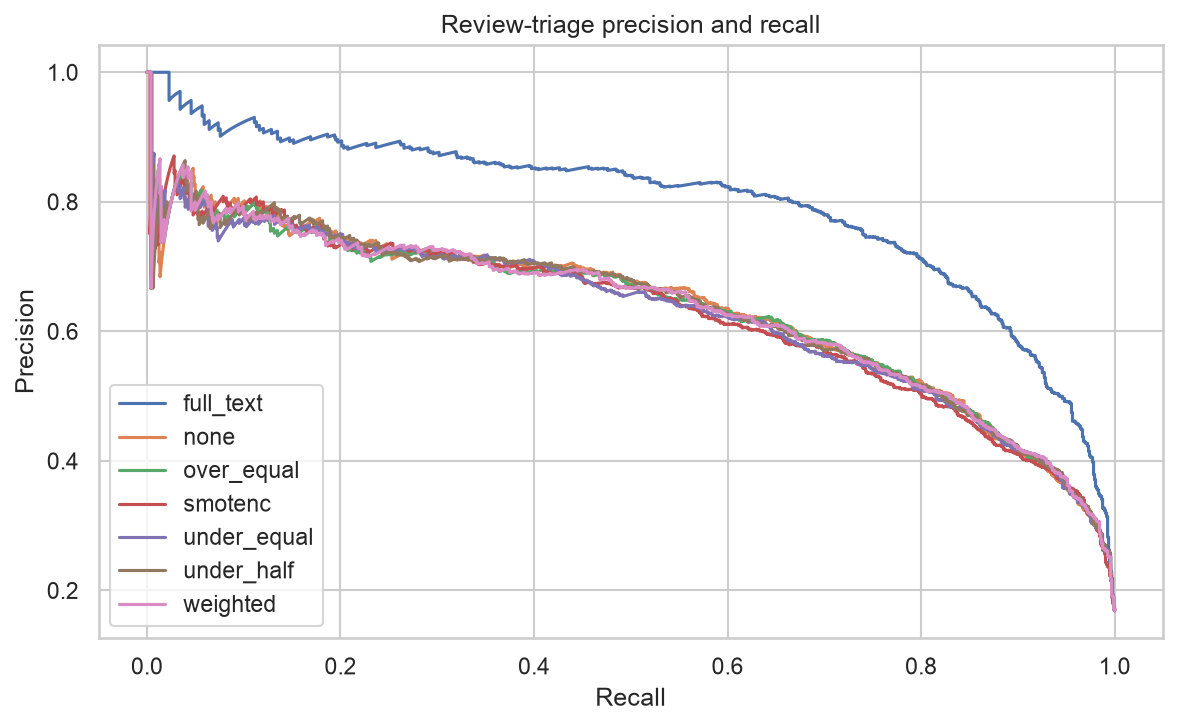

In [2]:
display(Image(filename=str(root / "reports/figures/precision_recall.png")))

### Operating Tradeoff

Actual saved run evidence; interpretation follows the protocol above.

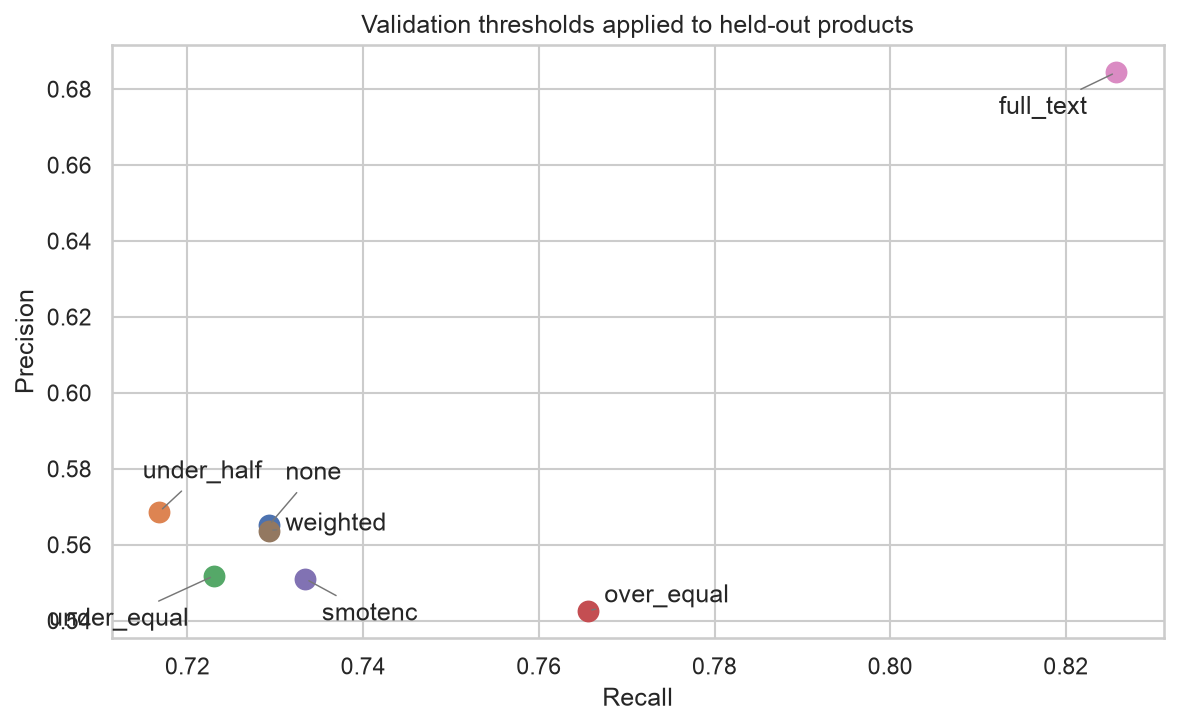

In [3]:
display(Image(filename=str(root / "reports/figures/operating_tradeoff.png")))

### Mcar20 Comparison

Actual saved run evidence; interpretation follows the protocol above.

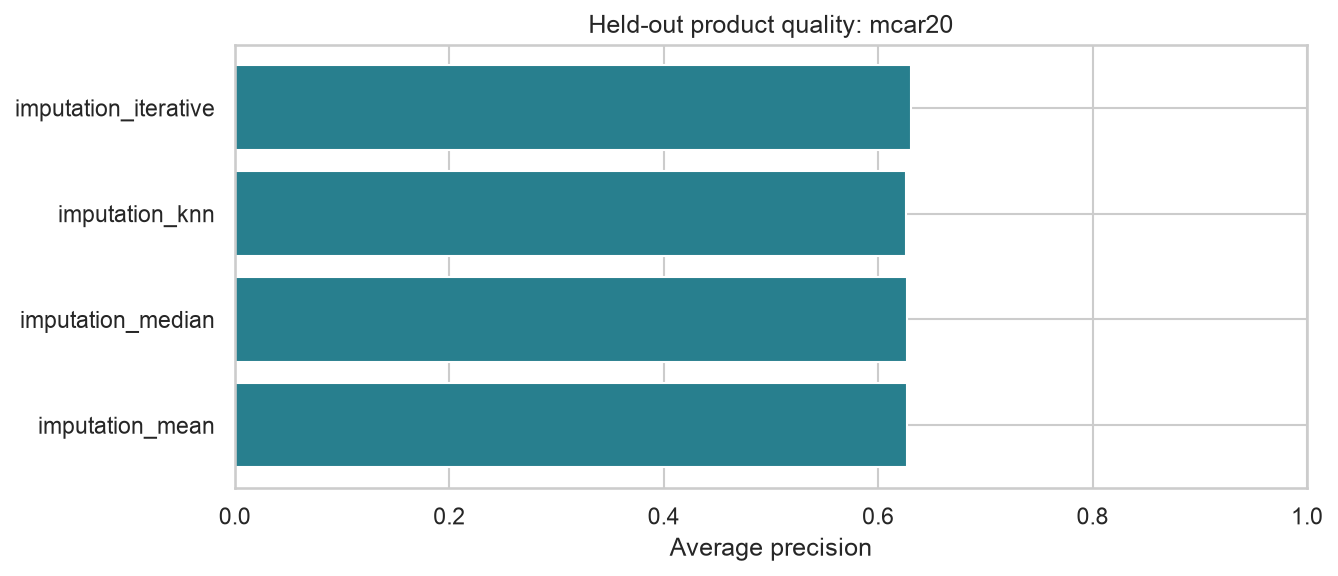

In [4]:
display(Image(filename=str(root / "reports/figures/mcar20_comparison.png")))

## Provenance

The following metadata records the execution environment, sources and configuration. Training is intentionally separate from this offline evidence walkthrough.

In [5]:
display(metadata)

{'seed': 42,
 'split_rows': {'train': 14158, 'validation': 2762, 'test': 5713},
 'positive_label': 'non-recommendation',
 'stress_scenario': '20% MCAR per numeric column; simulated, not source defects',
 'versions': {'scikit-learn': '1.9.1',
  'imbalanced-learn': '0.14.2',
  'pandas': '3.0.6',
  'numpy': '2.5.3'},
 'source_hashes': {'models.py': '037f9e4ed37e3ed215d87a686df12715382da67f7d1f3e60d469ca36a29875bd',
  'evaluation.py': 'a1b1e1df0974780c484581c87f5b3d5bb0e3febe2d6321cbd17b609428408ce4',
  '__init__.py': '9887c8ffedd49ac3bfa8f9ac4da046a04d29a3004cd4ccae53043d1ebb6fd0e7',
  'visualization.py': '82663f131a0108ef79fbb05256c8ac879986f820c554472ecdb2c059676f04f0',
  'cli.py': 'b4b34b91af20bf69436cc5f2e71367089b1f366a77bbeaee3d9aa3e684184361',
  'pipeline.py': 'aa9b156387e94a4870e0cf3f381adaf7649eb7727ecc339b5a4f8cd81e8237c2',
  'data.py': 'da64d6346f40241ebe01531f4af76814cd0f8d0c900381c8e8f208f2f64d127d'}}